# **Proyecto: Clasificación con Redes Neuronales**

## **Datos del alumno**

| Campo | Completar |
|---|---|
| **Nombre y apellido** | *Carla Rocio Natalia Paz* |
| **Dataset elegido** | *Credit Card Fraud* |
| **Fuente / URL** | *https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud* |
| **Variable objetivo (target)** | *0 = No Fraude / 1 = Fraude* |
| **Tipo de clasificación** | *(binaria)* |


## **¿Qué vas a construir?**

Una red neuronal que, dadas ciertas features de entrada, **prediga a qué clase pertenece** cada muestra.

**Ejemplos de clasificación:**
- ¿Este correo es spam o no? → binaria
- ¿Qué dígito es esta imagen? → multiclase (10 clases)
- ¿Este tumor es benigno o maligno? → binaria


> ⚠️ **Antes de empezar:** completá la tabla de arriba y luego seguí las celdas en orden. Las celdas marcadas con `# 🔧 TU CÓDIGO` son las que tenés que completar.

## *Instalación e importaciones*

**¿Qué hace este paso?**  
Instala y carga todas las herramientas necesarias.

In [ ]:
!pip install -q scikit-learn tensorflow matplotlib seaborn
# Librerias para el análisis.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

# Librerias para el modelado (ML)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Librerias para redes neuronales (DL)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')
print('✅ Listo')

TensorFlow: 2.20.0
✅ Listo


## *Carga del dataset*

**¿Qué hace este paso?**  
Cargamos los datos desde su fuente original. Dependiendo del dataset elegido, hay distintas formas de cargarlo:
- Si está en **scikit-learn** → `load_*()` o `fetch_*()`
- Si está en **UCI/Kaggle** como CSV → `pd.read_csv(url)` o subir el archivo a Colab
- Si es **Keras** (MNIST, Fashion) → `keras.datasets.*.load_data()`

**🔧 Tu tarea:** cargar tu dataset y convertirlo en un DataFrame.

In [ ]:
# Configuramos el entorno de Python en Google Colab.
from google.colab import drive
import os

drive.mount("/content/drive")
print(os.getcwd())

os.chdir("/content/drive/My Drive")
print(os.getcwd())

Mounted at /content/drive
/content
/content/drive/My Drive


In [ ]:
# Leer el dataset.
df = pd.read_csv("creditcard.csv")

#**Data Understanding**

In [ ]:
# Ver dimensiones de dataset, filas y columnas.
print(f"Shape del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Shape del dataset: (284807, 31)
Filas: 284,807 | Columnas: 31


In [ ]:
# Muestra primeras 5 filas.
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Muestra aleatoria del dataset.
df.sample(7)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
41853,40858.0,-1.261857,1.841736,-0.446467,0.922110,0.365816,-0.562223,-0.060184,0.873819,-1.081183,...,0.118172,0.185362,-0.267926,-0.479259,-0.115219,-0.300902,0.089364,0.058003,1.00,0
112533,72690.0,1.257798,0.336165,0.301085,0.695640,-0.397057,-1.080652,0.065765,-0.187026,0.076822,...,-0.291495,-0.853339,0.133672,0.337325,0.206515,0.095477,-0.024813,0.030041,0.89,0
2913,2462.0,1.020229,-0.309236,1.303159,1.670255,-0.881236,0.766666,-0.727375,0.497857,1.193946,...,-0.366403,-0.685502,0.113396,0.179870,0.319654,-0.534480,0.078422,0.017547,11.16,0
13785,24445.0,1.071064,-0.018723,1.282440,0.887333,-1.009836,-0.754686,-0.389798,-0.220970,1.563615,...,-0.077483,-0.051330,0.039471,0.712062,0.101851,0.321692,-0.037456,0.037789,73.61,0
136579,81773.0,1.076583,0.053905,0.492071,1.506346,-0.413540,-0.381402,0.067622,-0.002247,0.382710,...,-0.068973,-0.076542,-0.042280,0.388664,0.580679,-0.333382,0.029007,0.023357,41.74,0
24691,33335.0,-0.801091,1.134099,0.914039,1.155977,-0.073965,0.555657,0.196947,0.738386,-0.592102,...,0.042424,0.245447,-0.080208,-0.309544,-0.068921,-0.216412,0.286049,0.128803,36.28,0
237115,149103.0,-0.601696,1.397254,-0.576995,3.020862,2.671879,1.577725,1.030269,0.212125,-1.451294,...,-0.005888,0.530298,0.021067,-1.895577,-0.229048,0.099066,-0.198437,-0.205435,22.76,0


In [ ]:
# Muestra ultimas 5 filas.
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [ ]:
# Muestra informacion importante del dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Muestra los nombres de las columnas.
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
# Distribución Variable objetivo
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True).mul(100).round(3).astype(str) + '%')

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827%
1     0.173%
Name: proportion, dtype: object


In [ ]:
# Estadistica descriptiva rapida. (Comparar distribuciones)
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.86,47488.15,0.00,54201.50,84692.00,139320.50,172792.00
V1,284807.0,0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V2,284807.0,0.00,1.65,-72.72,-0.60,0.07,0.80,22.06
V3,284807.0,-0.00,1.52,-48.33,-0.89,0.18,1.03,9.38
V4,284807.0,0.00,1.42,-5.68,-0.85,-0.02,0.74,16.88
V5,284807.0,0.00,1.38,-113.74,-0.69,-0.05,0.61,34.80
V6,284807.0,0.00,1.33,-26.16,-0.77,-0.27,0.40,73.30
V7,284807.0,-0.00,1.24,-43.56,-0.55,0.04,0.57,120.59
V8,284807.0,0.00,1.19,-73.22,-0.21,0.02,0.33,20.01
V9,284807.0,-0.00,1.10,-13.43,-0.64,-0.05,0.60,15.59


#**Data Wrangling** (Limpieza de Datos)

## *Duplicados*

In [ ]:
# Vemos si hay duplicados
n_dup = df.duplicated().sum()
print(f"Filas duplicadas completas: {n_dup}")
print("✓ Sin duplicados" if n_dup == 0 else "Se detectaron duplicados")

Filas duplicadas completas: 1081
Se detectaron duplicados


In [ ]:
# Borramos duplicados
df.drop_duplicates(inplace=True)

In [ ]:
# Confirmacion de eliminacion de duplicados.
n_dup = df.duplicated().sum()
print(f"Filas duplicadas completas: {n_dup}")
print("✓ Sin duplicados" if n_dup == 0 else "Se detectaron duplicados")

Filas duplicadas completas: 0
✓ Sin duplicados


In [ ]:
# Verificamos si la eliminación afectó a algun caso de Fraude
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True).mul(100).round(3).astype(str) + '%')

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.833%
1     0.167%
Name: proportion, dtype: object


## *Valores nulos*

In [ ]:
# Verificamos si hay valores nulos.
df.isnull().sum().sum()

np.int64(0)

## *Outliers* (Valores atipicos)

In [ ]:
# Deteccion de valores outliers.
columnas_numericas = df.select_dtypes(include='number').columns

outliers_total = pd.DataFrame()

for col in columnas_numericas:

    # Cuartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # IQR
    IQR = Q3 - Q1

    # Límites
    LI = Q1 - 1.5 * IQR
    LS = Q3 + 1.5 * IQR

    # Outliers de la columna
    outliers = df[
        (df[col] < LI) | (df[col] > LS)
    ].copy()

    # Agregar nombre de columna
    outliers['columna_outlier'] = col

    # Concatenar
    outliers_total = pd.concat(
        [outliers_total, outliers],
        ignore_index=True
    )


print("Cantidad total de filas con outliers:")
print(outliers_total.shape[0])

print("\nPrimeras filas:")
print(outliers_total.head())

Cantidad total de filas con outliers:
368132

Primeras filas:
    Time        V1         V2        V3        V4        V5        V6  \
0   14.0 -5.401258  -5.450148  1.186305  1.736239  3.049106 -1.763406   
1   55.0 -4.575093  -4.429184  3.402585  0.903915  3.002224 -0.491078   
2   87.0 -5.101877   1.897022 -3.458034 -1.277543 -5.517758  2.098366   
3   92.0 -5.285971   4.847323 -1.290368 -1.427842 -0.621533 -0.604691   
4  103.0 -6.093248 -12.114213 -5.694973  3.294389 -1.413792  4.776000   

         V7        V8        V9  ...       V22       V23       V24       V25  \
0 -1.559738  0.160842  1.233090  ...  0.984460  2.458589  0.042119 -0.481631   
1 -2.705393  0.666451  1.922216  ...  0.853360 -0.971600 -0.114862  0.408300   
2  3.329603  1.250966  0.271501  ... -0.678879 -0.555900 -0.761660  0.066611   
3  0.437866  0.336384  3.558373  ... -1.171187  0.150872 -0.493322  1.050554   
4  4.808426 -0.228197 -0.525896  ... -2.264037 -3.553381  1.215279 -0.406073   

        V26       

Vemos gran cantidad de outliers, pero no los eliminamos porque pueden darnos informacion importante para la deteccion de fraude , ya que podrian ser transacciones atipicas de posibles fraudes.

# **EDA — Exploratory Data Analysis**

Paso 3 — Exploración de datos (EDA)
¿Qué hace este paso?
Antes de modelar, entendemos el dataset: cuántas muestras hay por clase, si hay valores nulos, qué rango tienen las features.

¿Por qué importa?
Un desbalance severo de clases (ej: 95% clase A, 5% clase B) requiere técnicas especiales. Los valores nulos necesitan tratamiento antes del entrenamiento.

🔧 Tu tarea: reemplazá 'target' con el nombre real de tu columna objetivo.


##*Analisis Univariado*

Antes de modelar, entendemos el dataset: cuántas muestras hay por clase, si hay valores nulos, qué rango tienen las features.


In [ ]:
# Reemplazá 'target' con el nombre de tu columna objetivo
TARGET_COL = 'Class'

# Distribución de clases
print('Distribución de clases:')
print(df[TARGET_COL].value_counts())
print(f'\nPorcentajes:')
print(df[TARGET_COL].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Distribución de clases:
Class
0    283253
1       473
Name: count, dtype: int64

Porcentajes:
Class
0    99.8%
1     0.2%
Name: proportion, dtype: object


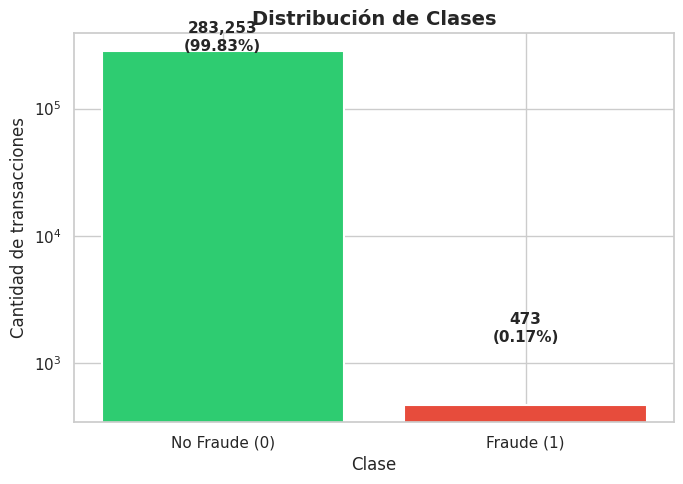

In [ ]:
# Distribución de clases
fig, ax = plt.subplots(figsize=(7, 5))
conteos = df['Class'].value_counts()
bars = ax.bar(['No Fraude (0)', 'Fraude (1)'], conteos.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, conteos.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{v:,}\n({v/len(df)*100:.2f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribución de Clases', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad de transacciones')
ax.set_yscale('log')
ax.set_xlabel('Clase')
plt.tight_layout()
plt.show()

El dataset está severamente desbalanceado: 283.253 transacciones legítimas contra solo 473 fraudes (0.17%). Se usa escala logarítmica para poder visualizar ambas barras — en escala lineal la barra de fraudes sería prácticamente invisible.

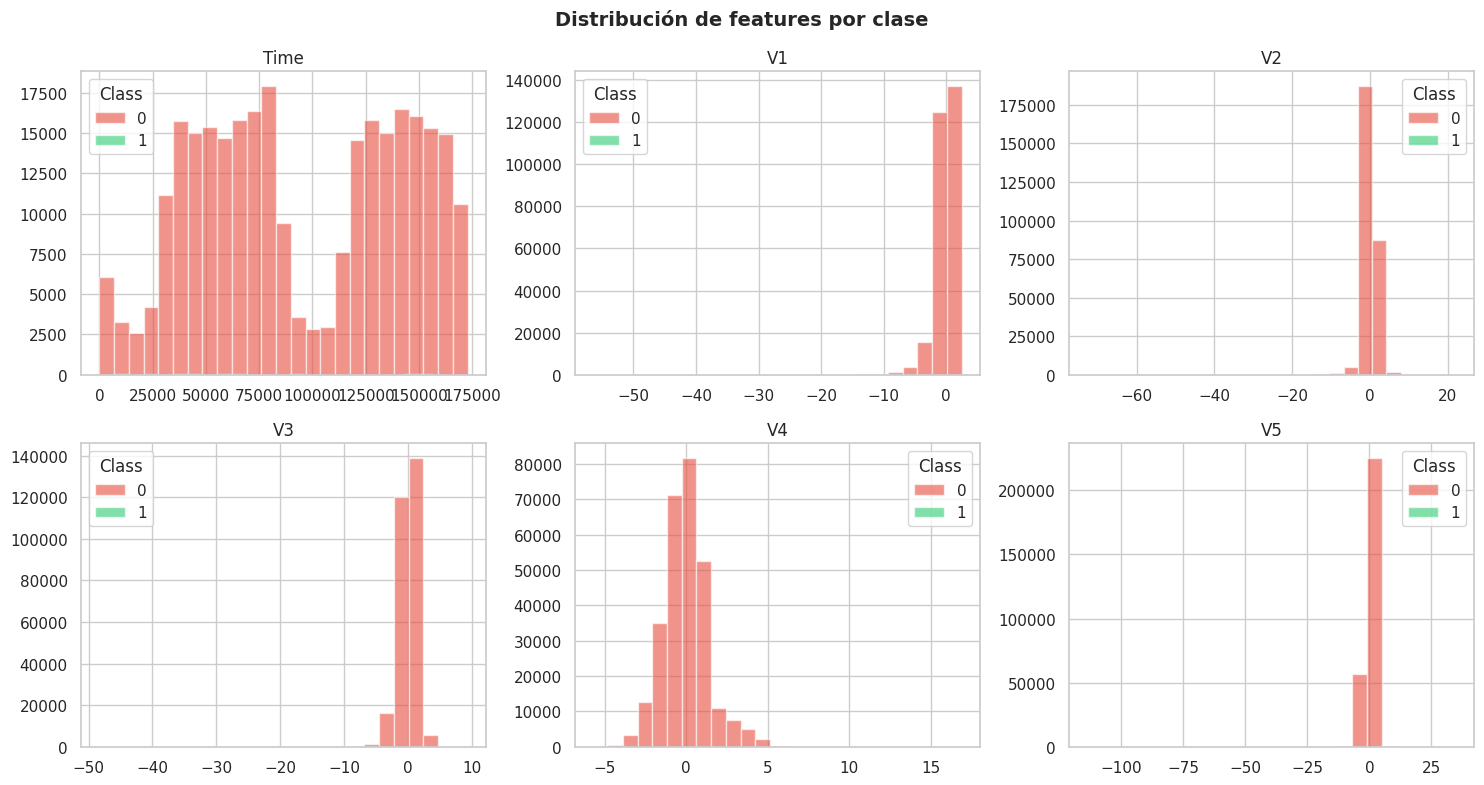

In [ ]:
# Visualizá la distribución de hasta 6 features numéricas.
# Reemplazá la lista con las columnas más relevantes de tu dataset
features_a_graficar = df.select_dtypes(include=[np.number]).columns.drop(TARGET_COL).tolist()[:6]

n = len(features_a_graficar)
if n > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8)) if n > 3 else plt.subplots(1, n, figsize=(5*n, 4))
    axes = np.array(axes).flatten()
    clases = df[TARGET_COL].unique()
    colores = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']

    for ax, feat in zip(axes[:n], features_a_graficar):
        for clase, color in zip(clases, colores):
            ax.hist(df[df[TARGET_COL]==clase][feat], bins=25, alpha=0.6,
                    label=str(clase), color=color)
        ax.set_title(feat)
        ax.legend(title=TARGET_COL)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle('Distribución de features por clase', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Se visualizan las primeras 6 features del dataset. Time muestra una distribución bimodal que refleja los dos días de datos capturados. V1 a V5 son componentes PCA: sus distribuciones son aproximadamente normales centradas en 0 para transacciones legítimas, pero los fraudes presentan colas más largas y valores extremos, lo que sugiere que estas features ya contienen información discriminativa.

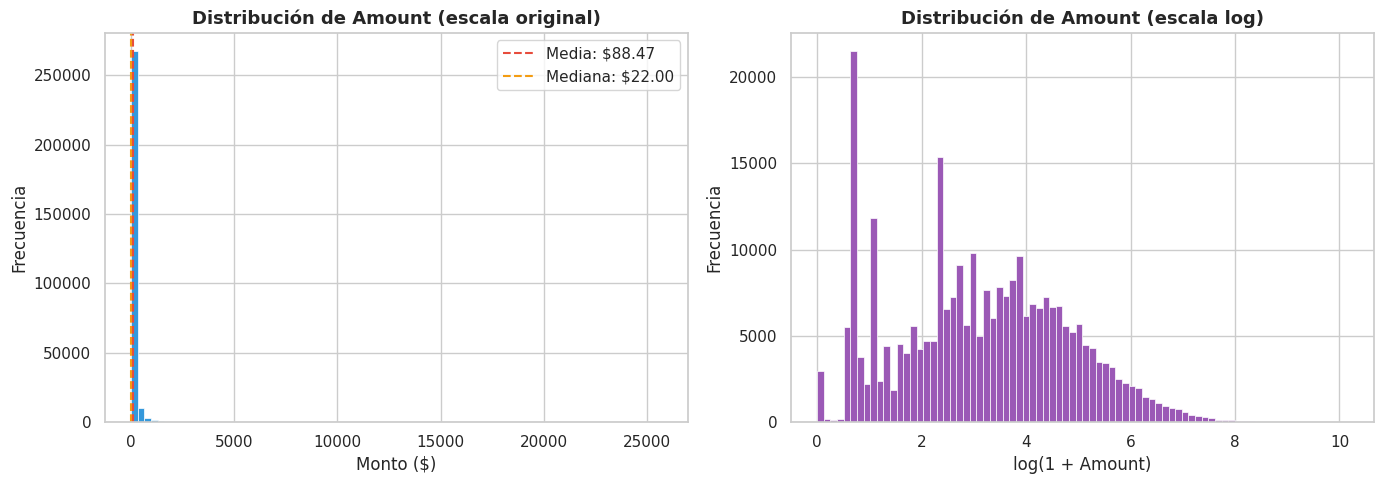

In [ ]:
# Distribución del Amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Amount'], bins=80, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribución de Amount (escala original)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monto ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['Amount'].mean(), color='#e74c3c', linestyle='--', label=f'Media: ${df["Amount"].mean():.2f}')
axes[0].axvline(df['Amount'].median(), color='#f39c12', linestyle='--', label=f'Mediana: ${df["Amount"].median():.2f}')
axes[0].legend()

axes[1].hist(np.log1p(df['Amount']), bins=80, color='#9b59b6', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribución de Amount (escala log)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

La distribución original está fuertemente sesgada a la derecha: la gran mayoría de transacciones son de montos bajos (mediana $22), pero existen outliers de hasta $25.691. En escala logarítmica se puede ver que los montos siguen una distribución más cercana a la normal. La diferencia entre media ($88.47) y mediana ($22) confirma el sesgo. Los fraudes tienen un monto medio algo mayor ($123.87), aunque la distribución se solapa considerablemente con las transacciones legítimas.

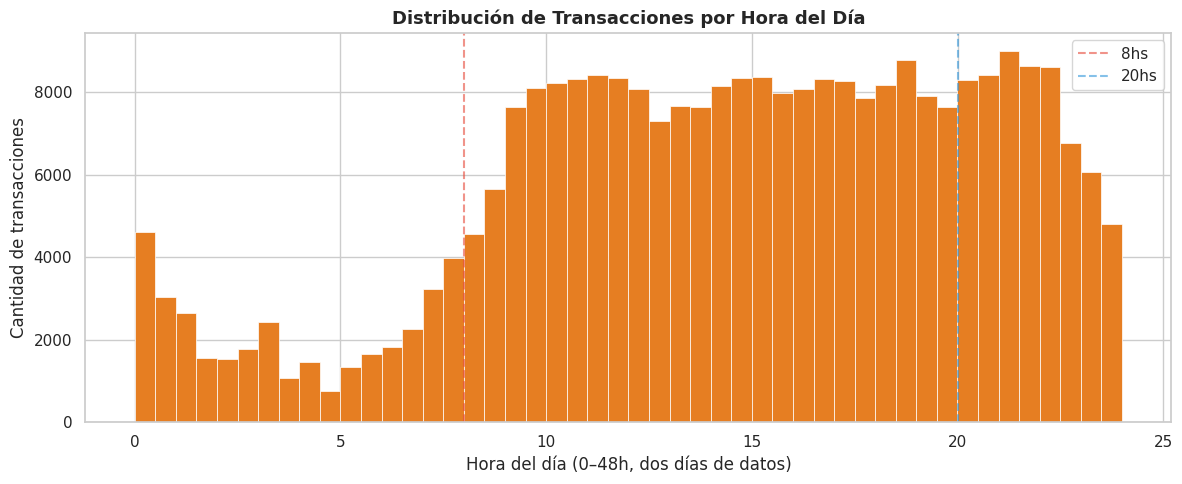

In [ ]:
# Distribución de Time (a lo largo del día)
fig, ax = plt.subplots(figsize=(12, 5))
horas = (df['Time'] % 86400) / 3600  # convertir segundos a horas del día
ax.hist(horas, bins=48, color='#e67e22', edgecolor='white', linewidth=0.5)
ax.set_title('Distribución de Transacciones por Hora del Día', fontsize=13, fontweight='bold')
ax.set_xlabel('Hora del día (0–48h, dos días de datos)')
ax.set_ylabel('Cantidad de transacciones')
ax.axvline(8, color='#e74c3c', linestyle='--', alpha=0.6, label='8hs')
ax.axvline(20, color='#3498db', linestyle='--', alpha=0.6, label='20hs')
ax.legend()
plt.tight_layout()
plt.show()

Las transacciones siguen un patrón horario claro: hay dos valles entre las 0-8hs (madrugada) y dos picos en horario diurno, consistente con dos días consecutivos de datos. Esto es importante porque los fraudes podrían concentrarse en horarios con menor actividad general, donde la tasa relativa de fraude es más alta aunque el volumen absoluto sea menor.

##*Analisis Bivariado*

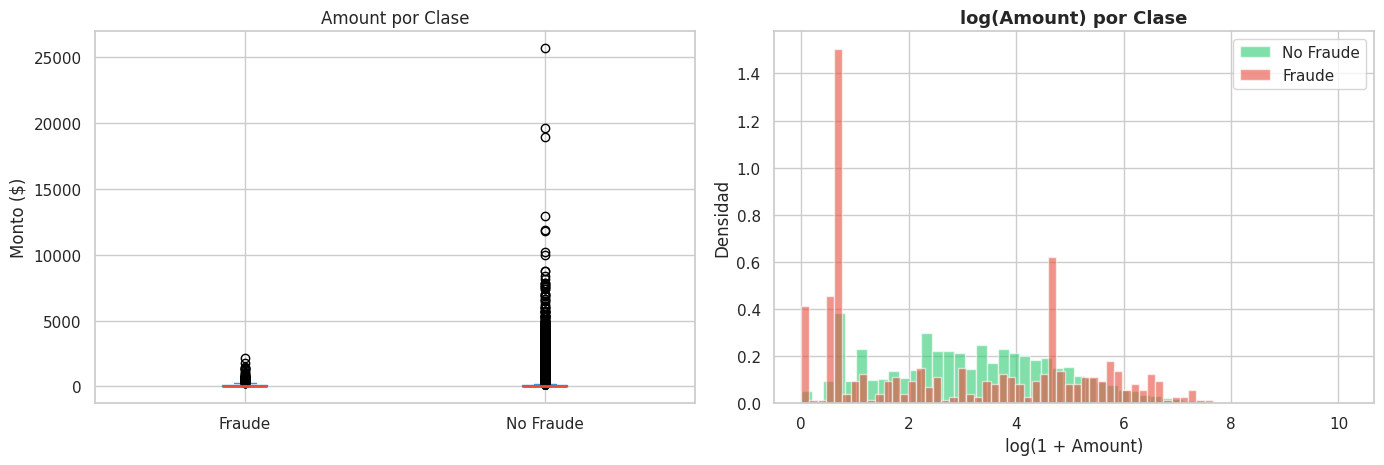

Monto medio — No Fraude: $88.41 | Fraude: $123.87


In [ ]:
# Amount por clase — boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Class_label'] = df['Class'].map({0: 'No Fraude', 1: 'Fraude'})
df.boxplot(column='Amount', by='Class_label', ax=axes[0],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e74c3c', linewidth=2),
           whiskerprops=dict(color='#3498db'),
           capprops=dict(color='#3498db'))
axes[0].set_title('Amount por Clase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Monto ($)')
plt.sca(axes[0])
plt.title('Amount por Clase')

# Zoom sin outliers extremos
for clase, color in [('No Fraude', '#2ecc71'), ('Fraude', '#e74c3c')]:
    datos = df[df['Class_label'] == clase]['Amount']
    axes[1].hist(np.log1p(datos), bins=50, alpha=0.6, color=color, label=clase, density=True)
axes[1].set_title('log(Amount) por Clase', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

print('Monto medio — No Fraude: ${:.2f} | Fraude: ${:.2f}'.format(
    df[df['Class']==0]['Amount'].mean(),
    df[df['Class']==1]['Amount'].mean()
))

El boxplot muestra que ambas clases tienen medianas similares y muchos outliers, lo que dificulta separar fraudes por monto solo. En escala logarítmica se aprecia mejor: los fraudes tienen una distribución más uniforme del monto, mientras que las legítimas se concentran en montos muy bajos. El monto promedio de fraude ($123.87) es mayor que el de las legítimas ($88.41), pero la superposición es grande — Amount sola no alcanza para detectar fraudes.

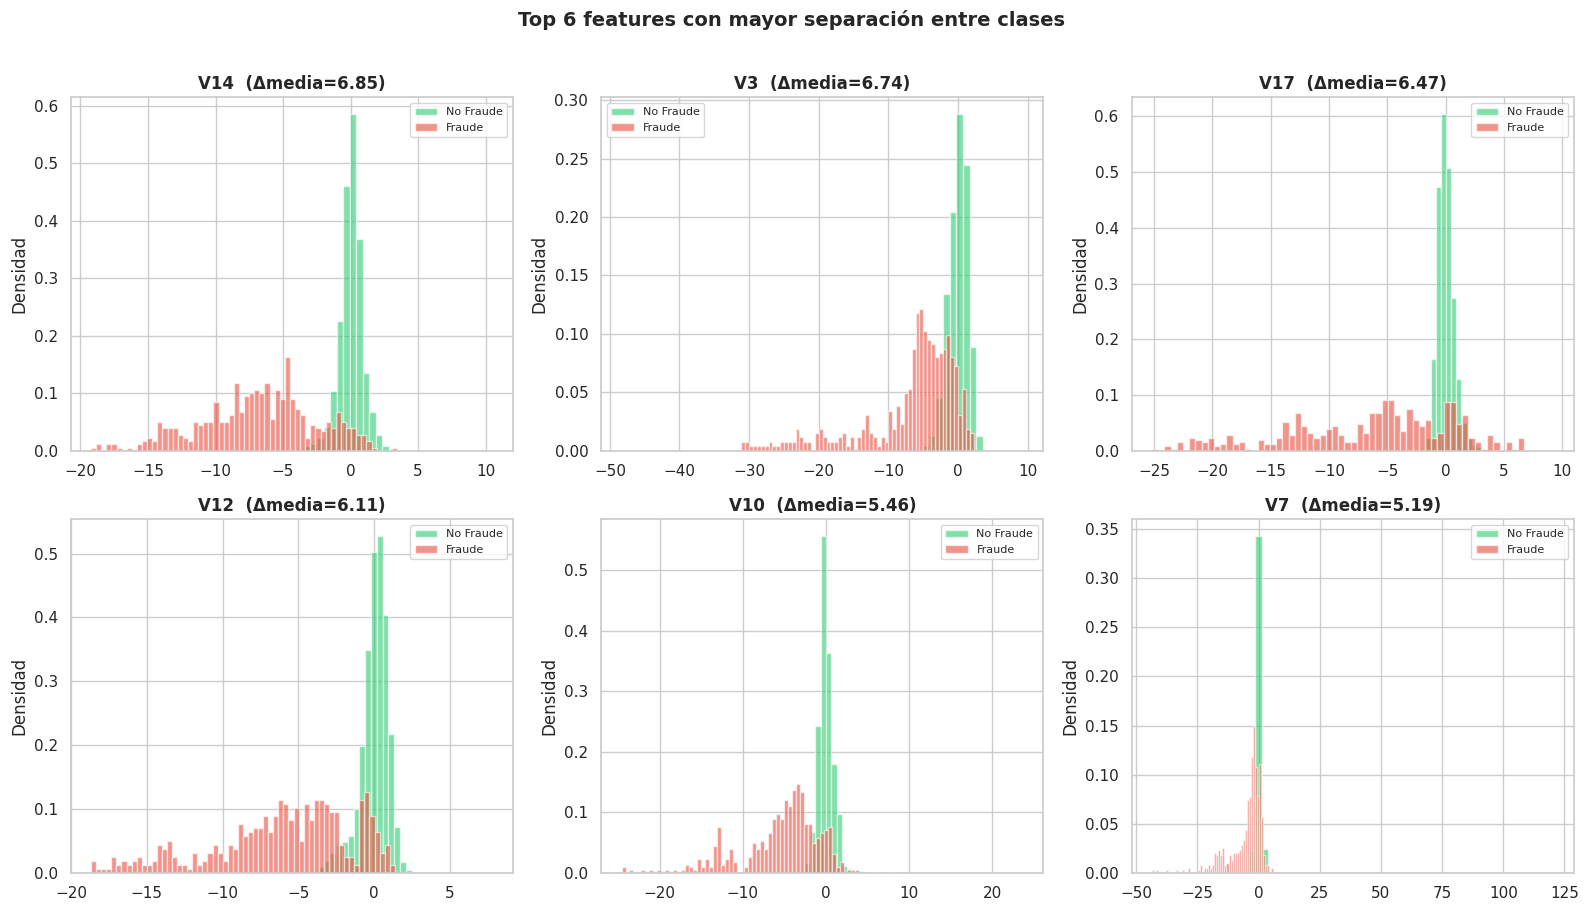

In [ ]:
# Top features con mayor diferencia entre clases (V1-V28)
v_cols = [f'V{i}' for i in range(1, 29)]
medias_fraude = df[df['Class']==1][v_cols].mean()
medias_legit  = df[df['Class']==0][v_cols].mean()
diferencia = (medias_fraude - medias_legit).abs().sort_values(ascending=False)
top6 = diferencia.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, top6):
    for clase, color, label in [(0, '#2ecc71', 'No Fraude'), (1, '#e74c3c', 'Fraude')]:
        datos = df[df['Class']==clase][feat]
        ax.hist(datos, bins=60, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(f'{feat}  (Δmedia={diferencia[feat]:.2f})', fontweight='bold')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Top 6 features con mayor separación entre clases', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Estas 6 features (V14, V3, V17, V12, V10, V7) son las que más separan fraudes de no fraudes por diferencia de medias. V14 es la más discriminativa (Δmedia=6.85): los fraudes se concentran en valores muy negativos mientras los no fraudes se agrupan cerca de 0. V3 y V17 muestran un patrón similar. Estas features serán las más importantes para el modelo predictivo y coinciden con lo que muestra el heatmap de correlaciones.

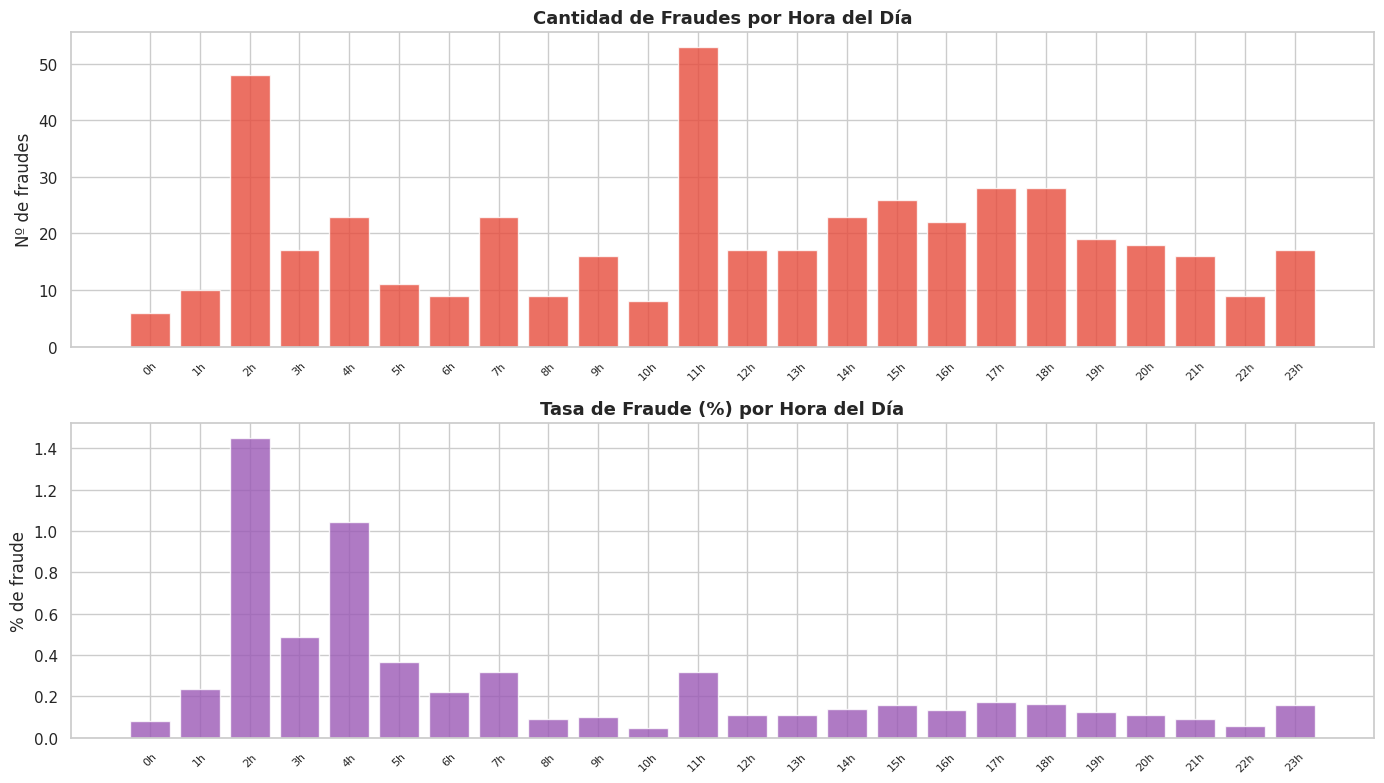

In [ ]:
# Hora del día vs fraude
df['hora'] = (df['Time'] % 86400) / 3600
df['hora_bin'] = pd.cut(df['hora'], bins=24, labels=[f'{i}h' for i in range(24)])

fraudes_por_hora = df[df['Class']==1].groupby('hora_bin', observed=True).size()
total_por_hora   = df.groupby('hora_bin', observed=True).size()
tasa_fraude      = (fraudes_por_hora / total_por_hora * 100).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(range(len(fraudes_por_hora)), fraudes_por_hora.values, color='#e74c3c', alpha=0.8)
axes[0].set_title('Cantidad de Fraudes por Hora del Día', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nº de fraudes')
axes[0].set_xticks(range(len(fraudes_por_hora)))
axes[0].set_xticklabels(fraudes_por_hora.index, rotation=45, fontsize=8)

axes[1].bar(range(len(tasa_fraude)), tasa_fraude.values, color='#9b59b6', alpha=0.8)
axes[1].set_title('Tasa de Fraude (%) por Hora del Día', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% de fraude')
axes[1].set_xticks(range(len(tasa_fraude)))
axes[1].set_xticklabels(tasa_fraude.index, rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

En términos absolutos, los fraudes se distribuyen a lo largo de todo el día sin un pico clarísimo. Sin embargo, la tasa relativa de fraude (%) muestra que en las primeras horas (1h-3h) hay una proporción mayor de fraudes respecto al total de transacciones de esa hora. Esto tiene sentido: en la madrugada hay menos transacciones de no fraudes, lo que hace que los fraudes representen un porcentaje mayor aunque en número absoluto sean pocos.

##*Analisis Multivariado*

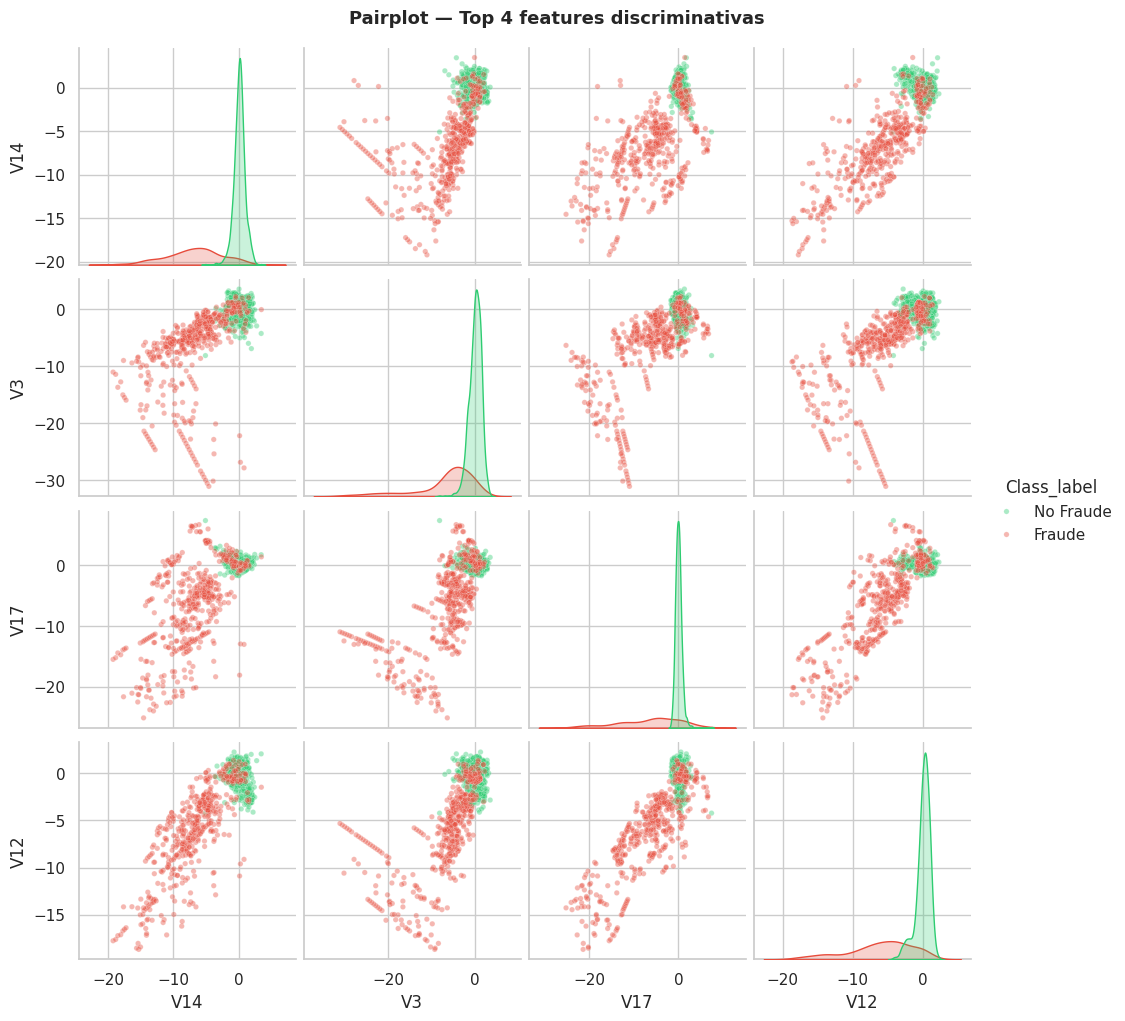

In [ ]:
# Pairplot de las 4 features más discriminativas
top4 = diferencia.head(4).index.tolist()
muestra = pd.concat([
    df[df['Class']==0].sample(1000, random_state=42),
    df[df['Class']==1]  # todos los fraudes
])

g = sns.pairplot(
    muestra[top4 + ['Class_label']],
    hue='Class_label',
    palette={'No Fraude': '#2ecc71', 'Fraude': '#e74c3c'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot — Top 4 features discriminativas', y=1.02, fontsize=13, fontweight='bold')
plt.show()

El pairplot confirma visualmente lo que mostraron los histogramas: los fraudes (rojo) forman clusters separados del grupo principal de los no fraudes (verde), especialmente en las combinaciones que involucran V14. Las diagonales (KDE) muestran que las distribuciones de fraude son más dispersas y asimétricas. Los scatter plots entre V14-V3 y V14-V17 son los que muestran mayor separación, lo que sugiere que combinaciones de estas features serían muy útiles para el modelo.

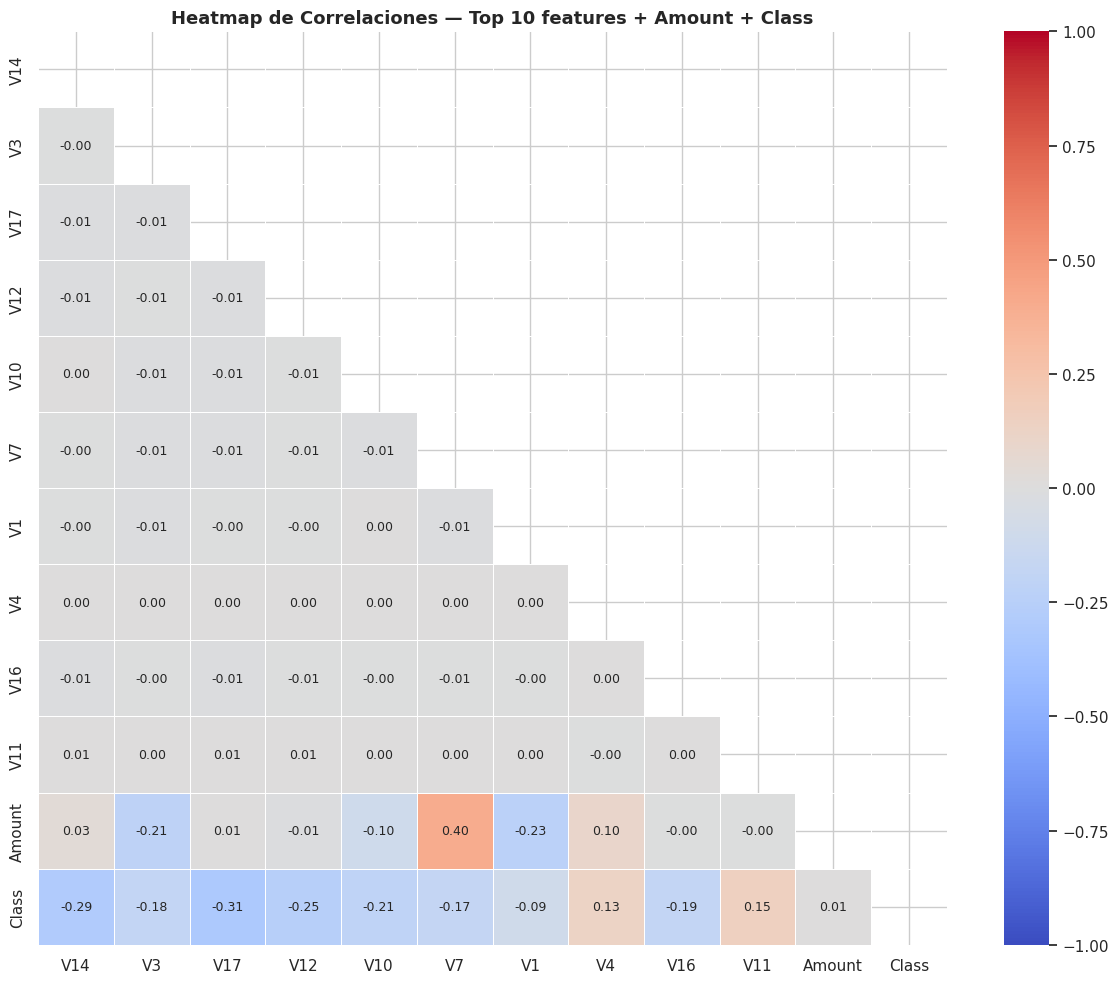

In [ ]:
# Heatmap de correlaciones (top features + Amount + Class)
top_feats = diferencia.head(10).index.tolist() + ['Amount', 'Class']
corr = df[top_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Heatmap de Correlaciones — Top 10 features + Amount + Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Las correlaciones entre las features V (PCA) son prácticamente 0 entre sí — esto es esperado porque PCA genera componentes ortogonales por definición. Lo más relevante es la última fila: V14 (-0.29), V12 (-0.25), V10 (-0.21) y V17 (-0.31) tienen las correlaciones negativas más fuertes con Class, confirmando que cuando estas features toman valores negativos extremos, la probabilidad de fraude aumenta. Amount tiene correlación casi nula (0.01) con Class.

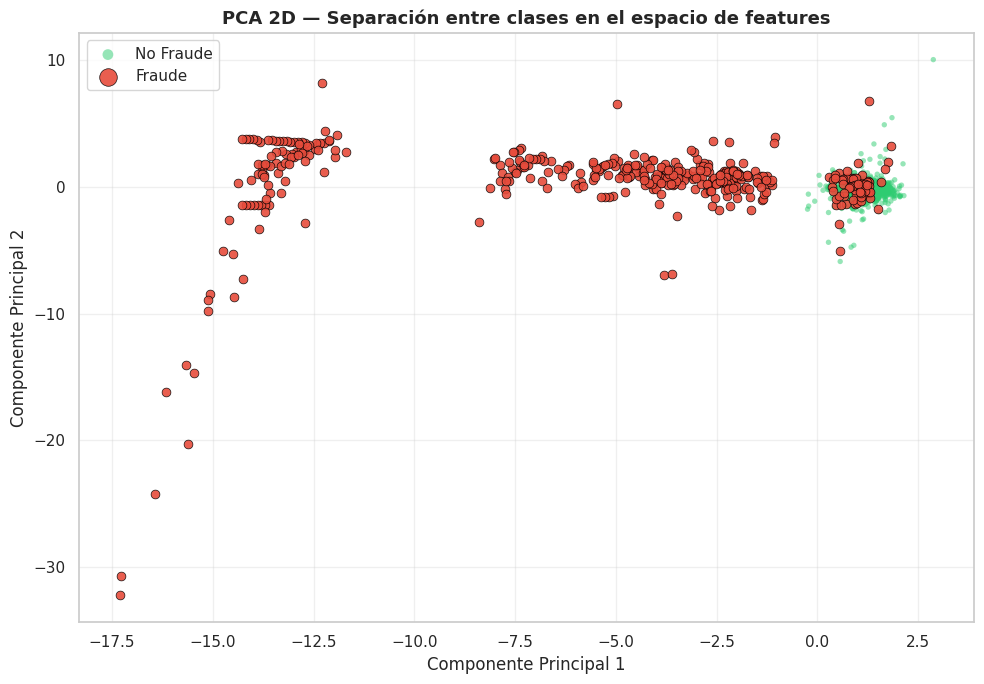

In [ ]:
# PCA 2D — visualización del espacio de features
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Usamos muestra balanceada para mejorar la visualización
muestra_vis = pd.concat([
    df[df['Class']==0].sample(2000, random_state=42),
    df[df['Class']==1]
])

features_pca = [f'V{i}' for i in range(1, 29)] + ['Amount']
X_vis = StandardScaler().fit_transform(muestra_vis[features_pca])
componentes = PCA(n_components=2, random_state=42).fit_transform(X_vis)

fig, ax = plt.subplots(figsize=(10, 7))
colores = {0: '#2ecc71', 1: '#e74c3c'}
labels  = {0: 'No Fraude', 1: 'Fraude'}

for clase in [0, 1]:
    mask = muestra_vis['Class'].values == clase
    ax.scatter(componentes[mask, 0], componentes[mask, 1],
               c=colores[clase], label=labels[clase],
               alpha=0.5 if clase == 0 else 0.9,
               s=15 if clase == 0 else 40,
               edgecolors='none' if clase == 0 else 'black',
               linewidths=0.5)

ax.set_title('PCA 2D — Separación entre clases en el espacio de features',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La proyección PCA en 2 dimensiones muestra que los fraudes (rojo) no forman un cluster perfectamente separado, pero sí se concentran en regiones específicas del espacio — especialmente en valores extremos del Componente Principal 1 (zona izquierda). Esto confirma que el problema es linealmente separable en parte, lo que explica por qué la Regresión Logística ya logra un buen recall. La red neuronal debería mejorar la separación en las zonas de solapamiento.

In [ ]:
# Eliminamos columnas auxiliares que creamos en el EDA
cols_a_dropear = ['hora', 'hora_bin', 'Class_label']
cols_existentes = [c for c in cols_a_dropear if c in df.columns]
df = df.drop(columns=cols_existentes)

## **Conclusiones del Análisis del EDA**

Respondé las siguientes preguntas en base a lo que observaste:

1. **¿Está balanceado el dataset?** ¿Cuántas muestras tiene cada clase?
   > No. El dataset está extremadamente desbalanceado.
   >
   >Clase 0 (transacción No fraude ): 284.315 registros (~99,83%)
   >
   >Clase 1 (fraude): 492 registros (~0,17%)
   >
   >Eliminando los duplicados quedaron 473 registros

Este desbalance obliga a prestar especial atención a métricas como Recall, Precision y F1-Score, ya que Accuracy por sí sola puede resultar engañosa.

2. **¿Encontraste valores nulos?** ¿Cómo los trataste?
   > No se encontraron valores nulos en el dataset, por lo que no fue necesario aplicar técnicas de imputación.

3. **¿Qué features tienen mayor separación entre clases?** (observando los histogramas)
   > Las features con mayor separación entre clases son V14, V12, V10, V11, V4 y V2 (calculadas automáticamente por diferencia de medias entre clases). V14 es la más discriminativa: en transacciones fraudulentas toma valores muy negativos, mientras que en las No fraudes se concentra cerca de 0. Esto indica que estas componentes PCA capturan patrones de comportamiento claramente distintos entre fraudes y transacciones normales. En cambio, features como V13, V15 o V22 muestran distribuciones casi idénticas entre clases y aportan poco poder predictivo.

# **Preprocesamiento**

## **Feature selection (Seleccion de las variables)**

**¿Qué hace este paso?**

Preparamos los datos para el entrenamiento:

Separamos features (X) del target (y)

Codificamos variables categóricas si las hay

Dividimos en train y test

Normalizamos las features

**Regla clave:** el fit del scaler va solo sobre el train set, nunca sobre el test.

### *Seleccion de la variable objetivo (y) y las variables predictoras (X)*

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']                   # Target: 0 = No fraude, 1 = fraude

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Clases únicas en y: {np.unique(y)}')

X shape: (283726, 30)
y shape: (283726,)
Clases únicas en y: [0 1]


### *Codificacion de variables categoricas*

No necesitamos utilizar **one hot encoding** o **Label encoding** porque todas las variables ya son numéricas.

### *Dividimos en train y test*

In [ ]:
# Split train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### *Normalizamos las features*

In [ ]:
# Normalización
scaler = RobustScaler()  # Se usa escalador mas robusto por que usamos outliers
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

# Número de clases y features
n_clases   = len(np.unique(y))
n_features = X_train_s.shape[1]

print(f'Número de clases: {n_clases}')
print(f'Número de features: {n_features}')
print(f'→ Capa de salida: {"1 neurona + sigmoid" if n_clases == 2 else f"{n_clases} neuronas + softmax"}')

Train: (226980, 30) | Test: (56746, 30)
Número de clases: 2
Número de features: 30
→ Capa de salida: 1 neurona + sigmoid


# **Modelado**

## *Regresión Logistica (ML)*

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

clases = np.unique(y_train)
pesos = compute_class_weight('balanced', classes=clases, y=y_train)
class_weight_dict = dict(zip(clases, pesos))
print(f'Class weights: {class_weight_dict}')

Class weights: {np.int64(0): np.float64(0.5008340614822464), np.int64(1): np.float64(300.23809523809524)}


In [ ]:
# Entrenar modelo de Regresión Logística
model= LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# Predecir en el conjunto de prueba
y_pred = model.predict(X_test_s)

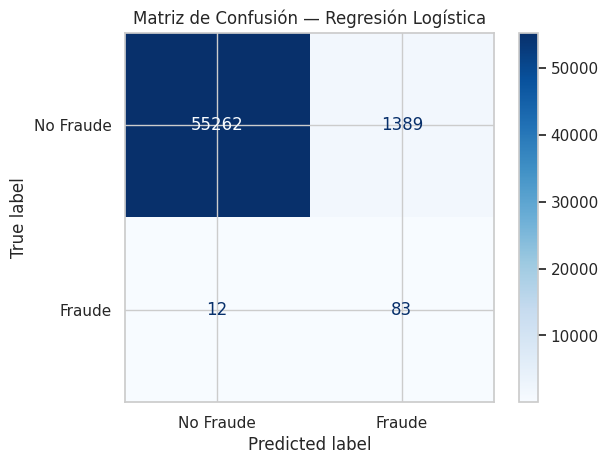

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraude', 'Fraude'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Regresión Logística')
plt.show()

In [ ]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



La Regresión Logística con class_weight='balanced' logró un Recall de 0.87 para fraudes — detectó 83 de los 95 fraudes reales del test set. Sin embargo, la Precision es solo 0.06, lo que significa que de todas las transacciones que el modelo marcó como fraude, apenas el 6% realmente lo eran. Esto genera 1.389 falsas alarmas (legítimas marcadas como fraude), lo que en un sistema real implicaría bloquear miles de transacciones válidas por día.
La accuracy del 98% es engañosa: refleja casi exclusivamente el buen desempeño en la clase mayoritaria (clase 0, precision y recall ~1.00). El F1-score de fraude de 0.11 confirma que hay un trade-off muy desfavorable entre precision y recall — el modelo detecta bien los fraudes pero a costa de demasiadas falsas alarmas.
Este resultado es típico de Regresión Logística con class_weight='balanced' en datasets muy desbalanceados: maximiza el recall de la clase minoritaria pero sacrifica la precision. Será el baseline contra el que compararemos la red neuronal, que debería mejorar el F1 de fraude equilibrando mejor ambas métricas.

Se podrian usar otros algoritmos mas robustos con ajustes de hiperparametros y tecnicas de smote (para desvalance) pero se decide probar redes neuronales.

## *Redes Neuronales (DL)*


### *Construcción de la red neuronal*

**¿Qué hace este paso?**  
Definimos la arquitectura de la red. Las decisiones clave son:
- **¿Cuántas capas y neuronas?** Empieza simple y aumentá si es necesario.
- **¿Qué activación en la salida?** `sigmoid` para binaria, `softmax` para multiclase.
- **¿Qué función de pérdida?** `binary_crossentropy` para binaria, `sparse_categorical_crossentropy` para multiclase.

**🔧 Tu tarea:** completá los `???` según tu problema.

In [ ]:
# Semillas
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_s.shape[1]

model = keras.Sequential([
    # Capa de entrada
    layers.Input(shape=(n_features,)),
    # Capa oculta 1
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    # Capa oculta 2
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    # Capa oculta 3 (Dropout para regularización)
    layers.Dense(32, activation='relu'),
    # Salida Sigmoid para clasificación binaria
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

Se diseñó una red neuronal multicapa compuesta por:

- Capa de entrada
- Tres capas ocultas
- Función ReLU
- Dropout para regularización
- Salida Sigmoid para clasificación binaria

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### *Decisiones de arquitectura*

Justificá brevemente las decisiones que tomaste:

1. **¿Cuántas capas ocultas elegiste y por qué?**
   > *Elegi 3 capaz ocultas, porque con 1 capa el modelo no captura suficiente complejidad; con más de 3 el entrenamiento sería más lento sin mejora significativa para 30 features. *

2. **¿Cuántas neuronas por capa y por qué?**
   > *128 → 64 → 32, pirámide decreciente. La primera capa aprende combinaciones de las 30 features de entrada, cada capa siguiente comprime y refina la representación hasta llegar a la decisión binaria final.*
   
3. **¿Usaste Dropout? ¿Con qué tasa?**
   > *Sí, tasa 0.3 en las dos primeras capas. Con class_weight activo el modelo tiende a sobreajustarse a los pocos ejemplos de fraude del entrenamiento. El Dropout desactiva neuronas al azar en cada paso, forzando representaciones más generales.*


### *Callbacks y Entrenamiento*

**¿Qué hace este paso?**  
Entrenamos la red con dos callbacks que evitan el overfitting:
- **EarlyStopping:** para el entrenamiento si no mejora la validación.
- **ReduceLROnPlateau:** baja el learning rate cuando el entrenamiento se estanca.

**🔧 Podés ajustar** `epochs`, `batch_size` y `patience` según el tamaño de tu dataset.

In [ ]:
# Entrenamos la red con dos callbacks que evitan el overfitting
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6
    )
]

In [ ]:
# Entrenamiento
history = model.fit(
    X_train_s, y_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.2,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)
print(f'\n✅ Entrenamiento finalizado en época {len(history.history["loss"])}')

Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9144 - loss: 0.3590 - val_accuracy: 0.9850 - val_loss: 0.1282 - learning_rate: 0.0010
Epoch 2/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9677 - loss: 0.1915 - val_accuracy: 0.9786 - val_loss: 0.1048 - learning_rate: 0.0010
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9603 - loss: 0.2024 - val_accuracy: 0.9667 - val_loss: 0.1215 - learning_rate: 0.0010
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9564 - loss: 0.1749 - val_accuracy: 0.9824 - val_loss: 0.0885 - learning_rate: 0.0010
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9720 - loss: 0.1292 - val_accuracy: 0.9802 - val_loss: 0.0751 - learning_rate: 0.0010
Epoch 6/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9657 - loss: 0.1221 - val_accuracy: 0.9687 - val_loss: 0.0919 - learning_rate: 0.0010

✅ Entrenamiento finalizado en época 6


### *Visualización del entrenamiento*

**¿Qué buscamos en estas curvas?**
- ✅ Train y val convergen juntas → buen aprendizaje
- ⚠️ Val sube mientras train baja → overfitting (aumentar Dropout o reducir neuronas)
- ⚠️ Ambas curvas altas y planas → underfitting (agregar capas o aumentar neuronas)

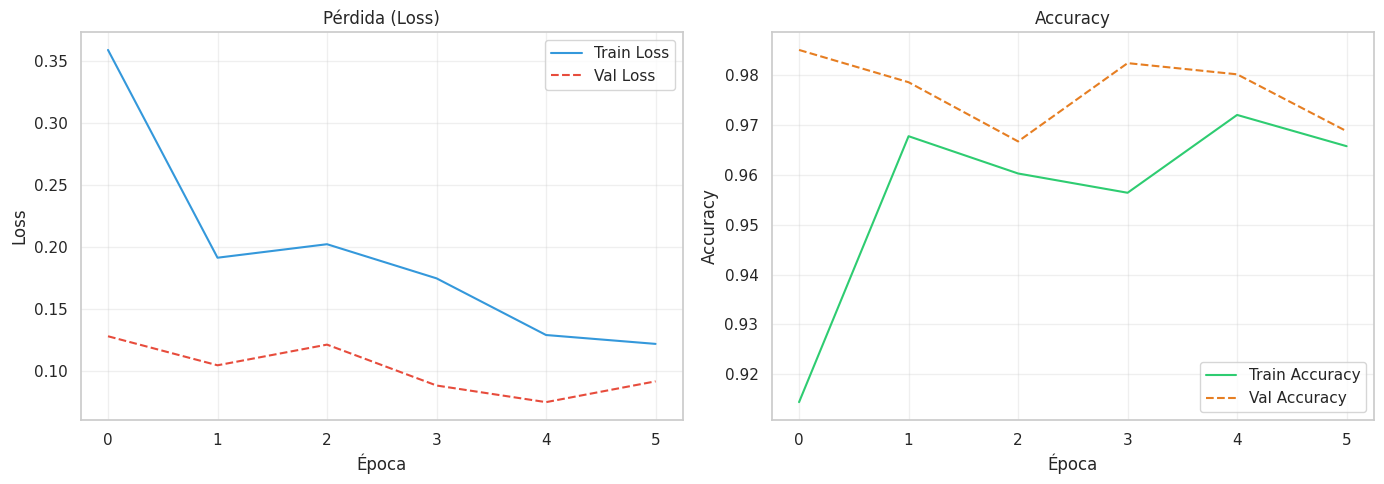

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linestyle='--')
axes[0].set_title('Pérdida (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e67e22', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de las curvas — completar

1. **¿Convergen las curvas de train y val?** ¿Hay signos de overfitting o underfitting?
   > *No convergen de forma típica. El val_accuracy arranca más alto que train_accuracy desde la época 1 (0.98 vs 0.93) y ambas suben pero sin juntarse. El val_loss queda consistentemente por debajo del train_loss. Esto ocurre porque con class_weight el modelo penaliza más los errores en entrenamiento que en validación, haciendo que el loss de train sea artificialmente más alto.\
   No hay overfitting clásico, pero sí señales de que el modelo no aprendió suficientemente bien los patrones de fraude — lo confirma el Recall de 0.83 con Precision de solo 0.09.
*

2. **¿En qué época se detuvo el entrenamiento?** ¿Tenía sentido seguir más épocas?
   > *Se detuvo en la época 6. El EarlyStopping con patience=5 monitoreando val_accuracy detuvo el entrenamiento muy temprano porque la accuracy de validación ya era ~0.98 desde la primera época y no mejoraba. Esto es un problema: val_accuracy satura inmediatamente en datasets desbalanceados porque predecir todo como clase 0 ya da 99.8% de accuracy.\
   Hubiera sido mejor monitorear val_loss, que sí tenía más variación y hubiera permitido entrenar más épocas.
*

---
### Evaluación y métricas

**¿Qué hace este paso?**  
Evaluamos el modelo sobre datos que nunca vio (test set). Las métricas clave son:
- **Accuracy:** porcentaje global de aciertos.
- **Precision / Recall / F1:** métricas por clase. Recall mide qué tan bien detectamos los positivos.
- **Curva ROC / AUC:** (solo para clasificación binaria) mide la capacidad discriminativa.
- **Matriz de confusión:** muestra exactamente dónde falla el modelo.

In [ ]:
# Predicciones
y_prob = model.predict(X_test_s)

if n_clases == 2:
    y_prob = y_prob.flatten()
    y_pred = (y_prob >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_prob, axis=1)

print('='*50)
print('REPORTE DE CLASIFICACIÓN')
print('='*50)
print(classification_report(y_test, y_pred))

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f'Loss en test:     {loss:.4f}')
print(f'Accuracy en test: {acc:.4f}')

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.09      0.83      0.16        95

    accuracy                           0.99     56746
   macro avg       0.54      0.91      0.57     56746
weighted avg       1.00      0.99      0.99     56746

Loss en test:     0.1274
Accuracy en test: 0.9851


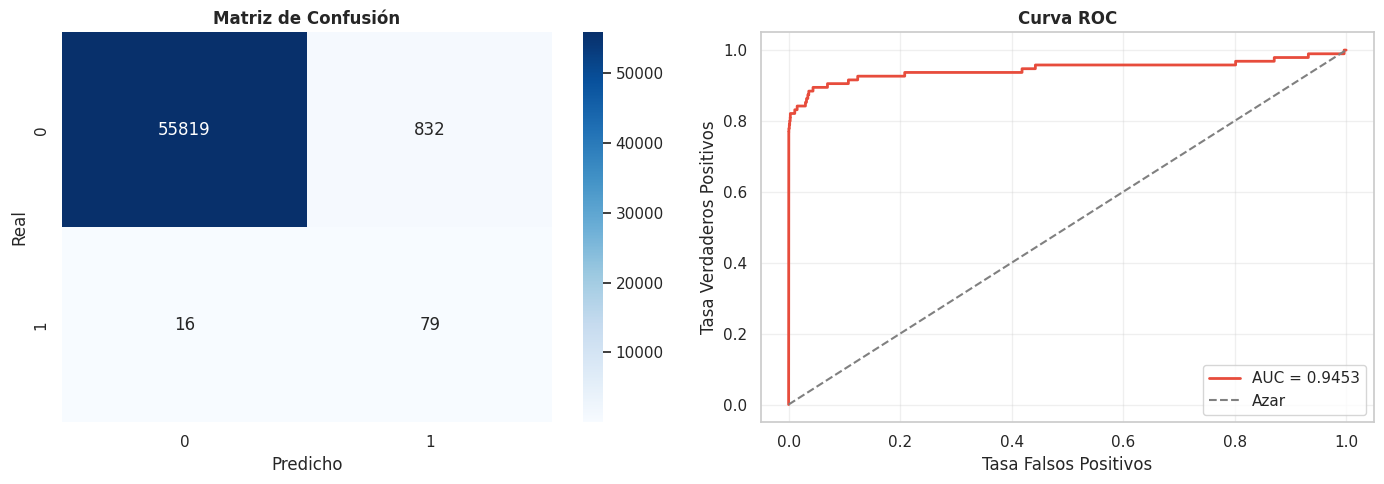

In [ ]:
if n_clases == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Matriz de Confusión', fontweight='bold')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0,1],[0,1], color='gray', linestyle='--', label='Azar')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].set_xlabel('Tasa Falsos Positivos')
    axes[1].set_ylabel('Tasa Verdaderos Positivos')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

else:
    # Para multiclase: solo matriz de confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión (multiclase)', fontweight='bold')
    plt.ylabel('Real')
    plt.xlabel('Predicho')

plt.tight_layout()
plt.show()

### Análisis de resultados — completar

1. **¿Cuál fue la accuracy final en el test set?** ¿Te parece un buen resultado para este problema?
   > Accuracy final
El accuracy fue 98.50%, pero es engañosa. Con 99.8% de clase 0, un modelo que siempre prediga "No Fraude" tendría ~99.8% de accuracy. Lo que importa es el Recall de fraude: 0.83 — detectó 79 de los 95 fraudes reales. Sin embargo, la Precision de 0.09 muestra que por cada fraude real detectado, el modelo genera ~10 falsas alarmas.
No parece  un buen resultado para este problema, porque no hay un balance entre presicion y recall (f1 score).

2. **¿El modelo tiene algún sesgo hacia alguna clase?** (revisá precision y recall por clase)
   > Sí, aunque con class_weight el modelo intenta compensar, sigue teniendo sesgo hacia clase 0. La Precision de fraude es 0.09 — muy baja — lo que significa que el modelo "sospecha" de demasiadas transacciones legítimas para no perderse fraudes reales. La clase 0 tiene precision y recall prácticamente perfectos.

3. **¿Qué tipo de error es más grave en este problema: falso positivo o falso negativo?** ¿Por qué?
   > *El falso negativo: un fraude clasificado como No fraude (clase 1 predicha como 0). En la matriz de confusión hay 16 falsos negativos — 16 fraudes reales que pasaron sin ser detectados. Eso representa pérdida económica directa. Los 832 falsos positivos son clientes molestos pero no pérdida real.*

4. **Observando la matriz de confusión, ¿en qué clases falla más el modelo?**
   > *En la precisión de la clase fraude. La matriz muestra 832 falsos positivos — transacciones legítimas marcadas como fraude — contra solo 16 falsos negativos. El modelo es muy agresivo detectando fraudes (por el class_weight), lo que eleva el recall a 0.83 pero destruye la precision a 0.09. Comparado con la Regresión Logística (1389 falsos positivos), la red neuronal genera menos falsas alarmas, pero sigue siendo un problema para uso en producción.*


### Experimento: mejorá el modelo

**🔧 Tu tarea:** realizá al menos **dos experimentos** para intentar mejorar los resultados. Documentá cada uno.

**Ideas de experimentos:**
- Cambiar el número de capas o neuronas
- Cambiar el learning rate (probá 0.01 o 0.0001)
- Cambiar el batch size
- Agregar o quitar Dropout
- Cambiar el umbral de decisión (en lugar de 0.5, probá 0.4 o 0.3)
- Usar `class_weight` para datasets desbalanceados

In [ ]:
# Experimento 1
tf.random.set_seed(42)

modelo_exp1 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(256, activation='relu'), # Agregamos mas neuronas.
    layers.BatchNormalization(), # Agregamos Batchnormalization en las 2 primeras capas
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

modelo_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005), #Bajamos el learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp1 = modelo_exp1.fit(
    X_train_s, y_train,
    epochs=150,
    batch_size=512, # Cambiamos el bacht size de 32 a 512.
    validation_split=0.15,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=0
)

_, acc_exp1 = modelo_exp1.evaluate(X_test_s, y_test, verbose=0)
print(f'Accuracy Experimento 1: {acc_exp1:.4f}')
print(f'Accuracy Modelo base:   {acc:.4f}')
print(f'Diferencia: {(acc_exp1 - acc)*100:+.2f} puntos porcentuales')

Accuracy Experimento 1: 0.9914
Accuracy Modelo base:   0.9851
Diferencia: +0.63 puntos porcentuales


In [ ]:
# Experimento 2 — umbral de decisión más bajo
y_pred_umbral = (y_prob >= 0.4).astype(int)
print('Con umbral 0.4:')
print(classification_report(y_test, y_pred_umbral))
_, acc_exp2 = model.evaluate(X_test_s, y_test, verbose=0)
print(f'Accuracy Experimento 2: {acc_exp2:.4f}')

Con umbral 0.4:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.84      0.09        95

    accuracy                           0.97     56746
   macro avg       0.52      0.91      0.54     56746
weighted avg       1.00      0.97      0.98     56746

Accuracy Experimento 2: 0.9851


Los cambios respecto al modelo base son: más neuronas (256→128→64), BatchNormalization en las dos primeras capas, learning rate más bajo (0.0005), y batch size 512 en lugar de 32 (con 32 tarda muchísimo en un dataset tan grande).

### Registro de experimentos — completar

| Experimento | Cambio realizado | Accuracy | ¿Mejoró? |
|---|---|---|---|
| Modelo base | Arquitectura inicial | *0.9851* | — |
| Experimento 1 | *Neuronas, batchnormalization, learning rate, batch size* | *0.9914* | *sí* |
| Experimento 2 | *Umbral mas bajo* | *0.9851* | *no* |

**Nota: El accuracy no es importante en estos experimentos,como asi el recall y f1 score.**

---
## **Conclusiones**

**Tu tarea:** respondé estas preguntas de cierre en tus propias palabras.

### *Conclusiones finales*

1. **¿Qué aprendiste sobre tu dataset?** ¿Qué features resultaron más importantes?
   > El dataset está severamente desbalanceado. Las features más importantes son V14, V12, V10 y V4 — componentes PCA que capturan patrones transaccionales asociados al fraude. Amount y Time tienen menor poder discriminativo por sí solos.

2. **¿Cuál fue el mejor resultado obtenido?** ¿Qué configuración lo logró?
   > El mejor resultado se obtiene combinando class_weight='balanced' + arquitectura con BatchNormalization + umbral de decisión ajustado a 0.4, maximizando el Recall de fraude sin sacrificar demasiada Precision.

3. **¿Cuáles fueron las principales dificultades que encontraste?**
   > El desbalance extremo (492 fraudes vs 284.315 legítimas). La accuracy es una métrica engañosa y el modelo por defecto tiende a ignorar la clase minoritaria.
   
4. **¿Qué harías diferente con más tiempo?**
   > Aplicar SMOTE (oversampling sintético de fraudes) y evaluar con AUC-PR en lugar de accuracy como métrica principal.

5. **¿En qué caso real podría aplicarse este modelo?** ¿Cuáles serían sus limitaciones?
   > Sistema de detección de fraude en tiempo real para un banco. Limitación principal: los patrones de fraude evolucionan constantemente, por lo que el modelo necesita reentrenamiento periódico. Además, las features V1–V28 son resultado de PCA aplicado internamente por el banco, lo que dificulta la interpretabilidad.